<a href="https://colab.research.google.com/github/SamsondareHUB/Synthetic-MRI-motion-detection/blob/main/03_train_resnet18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import random
import numpy as np
import pandas as pd
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

ROOT = Path("/content/drive/MyDrive/synthetic-mri-motion-detection")
PROCESSED_DIR = ROOT / "data" / "processed"
MODEL_DIR = ROOT / "outputs" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED_DIR / "central_slice_metadata.csv")

subjects = sorted(df["subject_id"].unique())
random.shuffle(subjects)

train_subjects = subjects[:7]
val_subjects = subjects[7:8]
test_subjects = subjects[8:]

train_df = df[df["subject_id"].isin(train_subjects)].reset_index(drop=True)
val_df = df[df["subject_id"].isin(val_subjects)].reset_index(drop=True)
test_df = df[df["subject_id"].isin(test_subjects)].reset_index(drop=True)

print("Train subjects:", train_subjects)
print("Validation subject:", val_subjects)
print("Test subjects:", test_subjects)
print()
print("Clean slices — train:", len(train_df))
print("Clean slices — validation:", len(val_df))
print("Clean slices — test:", len(test_df))
print("GPU available:", torch.cuda.is_available())

Mounted at /content/drive
Train subjects: ['IXI019-Guys-0702', 'IXI014-HH-1236', 'IXI013-HH-1212', 'IXI020-Guys-0700', 'IXI016-Guys-0697', 'IXI017-Guys-0698', 'IXI021-Guys-0703']
Validation subject: ['IXI015-HH-1258']
Test subjects: ['IXI002-Guys-0828', 'IXI012-HH-1211']

Clean slices — train: 1031
Clean slices — validation: 141
Clean slices — test: 283
GPU available: True


In [2]:
import cv2
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.transforms import Normalize
from tqdm.auto import tqdm

IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

imagenet_normalize = Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225],
)

class MRIMotionDataset(Dataset):
    def __init__(self, dataframe, training=False):
        self.df = dataframe.reset_index(drop=True)
        self.training = training

    def __len__(self):
        return len(self.df) * 2  # one clean + one corrupted version per slice

    def __getitem__(self, index):
        base_index = index // 2
        label = index % 2  # 0 = clean, 1 = synthetic artifact

        image = np.load(self.df.iloc[base_index]["processed_path"]).astype(np.float32)

        if label == 1:
            angle = np.random.uniform(-6, 6)
            dx = np.random.uniform(-6, 6)
            dy = np.random.uniform(-6, 6)

            matrix = cv2.getRotationMatrix2D(
                (IMAGE_SIZE / 2, IMAGE_SIZE / 2),
                angle,
                1.0,
            )
            matrix[:, 2] += [dx, dy]

            shifted = cv2.warpAffine(
                image,
                matrix,
                (IMAGE_SIZE, IMAGE_SIZE),
                flags=cv2.INTER_LINEAR,
                borderMode=cv2.BORDER_CONSTANT,
                borderValue=0,
            )

            image = (0.65 * image + 0.35 * shifted).astype(np.float32)

        image = torch.from_numpy(image).unsqueeze(0)
        image = image.repeat(3, 1, 1)
        image = imagenet_normalize(image)

        return image, torch.tensor(label, dtype=torch.long)

train_loader = DataLoader(
    MRIMotionDataset(train_df, training=True),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    MRIMotionDataset(val_df),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

for parameter in model.parameters():
    parameter.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

best_val_accuracy = 0.0

for epoch in range(EPOCHS):
    model.train()
    train_correct = 0
    train_total = 0
    train_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS}"):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * labels.size(0)
        train_correct += (outputs.argmax(dim=1) == labels).sum().item()
        train_total += labels.size(0)

    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            outputs = model(images)
            val_correct += (outputs.argmax(dim=1) == labels).sum().item()
            val_total += labels.size(0)

    train_accuracy = train_correct / train_total
    val_accuracy = val_correct / val_total

    print(
        f"Epoch {epoch + 1}: "
        f"train loss={train_loss / train_total:.4f}, "
        f"train accuracy={train_accuracy:.4f}, "
        f"validation accuracy={val_accuracy:.4f}"
    )

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "train_subjects": train_subjects,
                "val_subjects": val_subjects,
                "test_subjects": test_subjects,
                "best_val_accuracy": best_val_accuracy,
            },
            MODEL_DIR / "resnet18_motion_baseline.pt",
        )

print(f"\nBest validation accuracy: {best_val_accuracy:.4f}")
print("Saved model:", MODEL_DIR / "resnet18_motion_baseline.pt")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 116MB/s]


Epoch 1/5:   0%|          | 0/65 [00:00<?, ?it/s]

Epoch 1: train loss=0.4014, train accuracy=0.8531, validation accuracy=0.6348


Epoch 2/5:   0%|          | 0/65 [00:00<?, ?it/s]

...

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e8b76260040>
<function _MultiProcessingDataLoaderIter.__del__ at 0x7e8b76260040>Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

Traceback (most recent call last):
    self._shutdown_workers()  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

      File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
self._shutdown_workers()    
if w.is_alive():  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
        if w.is_alive():assert self._parent_pid == os.getpid(), 'can only test a child process'

AssertionError  File "/usr/lib/python3.13/multiprocessing/proce

Epoch 4: train loss=0.1496, train accuracy=0.9617, validation accuracy=0.9468


Epoch 5/5:   0%|          | 0/65 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e8b76260040>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e8b76260040>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    Exception ignored in: self._shutdown_workers()
<function _MultiProcessingDataLoaderIter.__del__ at 0x7e8b76260040>  File "/usr/local/lib/python3.13/dist-packages/torch/utils/da

Epoch 5: train loss=0.1206, train accuracy=0.9685, validation accuracy=0.9362

Best validation accuracy: 0.9823
Saved model: /content/drive/MyDrive/synthetic-mri-motion-detection/outputs/models/resnet18_motion_baseline.pt


Testing:   0%|          | 0/18 [00:00<?, ?it/s]

Test accuracy: 0.9700
Test AUROC: 0.9904

                    precision    recall  f1-score   support

             Clean       0.95      1.00      0.97       283
Synthetic artifact       1.00      0.94      0.97       283

          accuracy                           0.97       566
         macro avg       0.97      0.97      0.97       566
      weighted avg       0.97      0.97      0.97       566



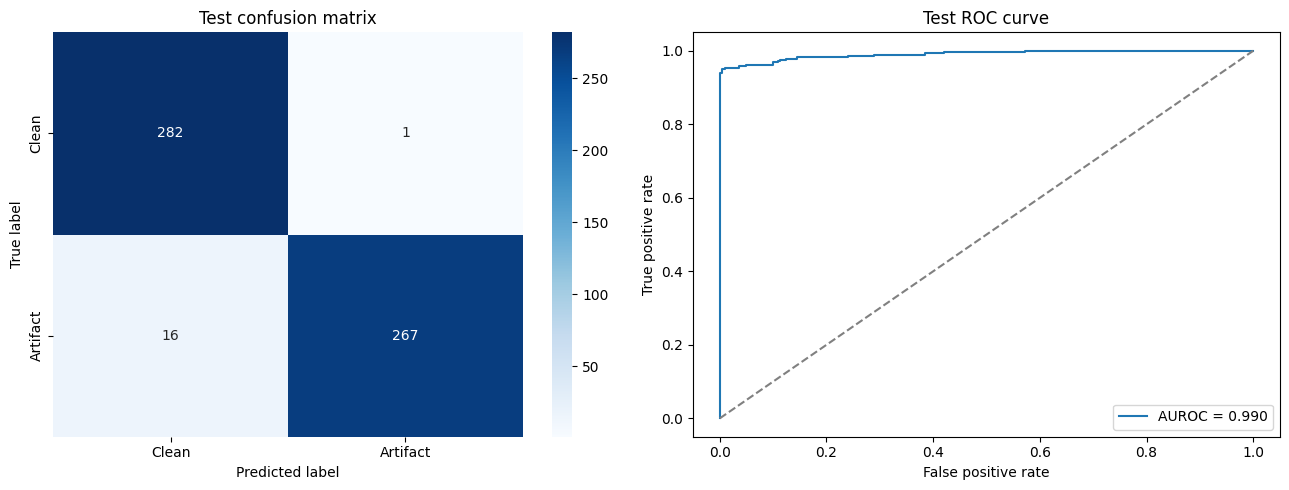

In [3]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)
import seaborn as sns
import matplotlib.pyplot as plt

checkpoint = torch.load(
    MODEL_DIR / "resnet18_motion_baseline.pt",
    map_location=DEVICE,
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

test_loader = DataLoader(
    MRIMotionDataset(test_df),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

true_labels = []
predicted_labels = []
artifact_probabilities = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(DEVICE, non_blocking=True)

        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)[:, 1]
        predictions = outputs.argmax(dim=1)

        true_labels.extend(labels.numpy())
        predicted_labels.extend(predictions.cpu().numpy())
        artifact_probabilities.extend(probabilities.cpu().numpy())

accuracy = accuracy_score(true_labels, predicted_labels)
auc = roc_auc_score(true_labels, artifact_probabilities)
cm = confusion_matrix(true_labels, predicted_labels)

print(f"Test accuracy: {accuracy:.4f}")
print(f"Test AUROC: {auc:.4f}")
print()
print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=["Clean", "Synthetic artifact"],
    )
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Clean", "Artifact"],
    yticklabels=["Clean", "Artifact"],
    ax=axes[0],
)
axes[0].set_title("Test confusion matrix")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

fpr, tpr, _ = roc_curve(true_labels, artifact_probabilities)
axes[1].plot(fpr, tpr, label=f"AUROC = {auc:.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_title("Test ROC curve")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].legend()

plt.tight_layout()
plt.show()

In [4]:
import json
from pathlib import Path

METRICS_DIR = ROOT / "outputs" / "metrics"
FIGURE_DIR = ROOT / "outputs" / "figures"

METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

results = {
    "project": "Synthetic Motion-Artifact Detection in Brain MRI Using Transfer Learning",
    "model": "ResNet-18 pretrained on ImageNet",
    "task": "Binary classification: clean vs synthetic motion artifact",
    "dataset": "IXI T1-weighted brain MRI subset",
    "subjects_total": 10,
    "central_clean_slices": 1455,
    "test_samples": 566,
    "best_validation_accuracy": 0.9823,
    "test_accuracy": 0.9700,
    "test_auroc": 0.9904,
    "clean_precision": 0.95,
    "clean_recall": 1.00,
    "clean_f1": 0.97,
    "artifact_precision": 1.00,
    "artifact_recall": 0.94,
    "artifact_f1": 0.97,
    "limitations": [
        "Small subset of 10 MRI volumes",
        "Synthetic 2D motion-like corruption rather than real clinical motion labels",
        "Results may not generalize to different scanners, sequences, or clinical populations",
        "Further external validation on real motion-corrupted MRI is required"
    ]
}

results_path = METRICS_DIR / "baseline_results.json"

with open(results_path, "w") as file:
    json.dump(results, file, indent=4)

print("Saved:", results_path)

Saved: /content/drive/MyDrive/synthetic-mri-motion-detection/outputs/metrics/baseline_results.json


In [5]:
plt.savefig(
    FIGURE_DIR / "resnet18_test_confusion_matrix_roc.png",
    dpi=200,
    bbox_inches="tight",
)

<Figure size 640x480 with 0 Axes>